# BÀI TẬP: E-COMMERCE DATA (ONLINE RETAIL)
**Nguồn:** kaggle.com/datasets/carrie1/ecommerce-data (541,909 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')

csv_path = 'https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv'

df = pd.read_csv(csv_path, encoding='ISO-8859-1', on_bad_lines='skip')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/retail-data/all/online-retail-dataset.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [26]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 33.1 MB


## A.2. Missing values & Duplicate data

In [84]:
missing = df.isnull().sum()
if(missing.sum()>0):
    print("Missing values: ", missing[missing>0])
else:
    print("No missing value")

print()
print("Duplicate rows (toan bo): ", df.duplicated().sum())
print("Duplicate theo khoa StockCode va Description", df.duplicated(subset=['StockCode','Description']).sum())


Missing values:  Description      1454
CustomerID     135080
dtype: int64

Duplicate rows (toan bo):  5268
Duplicate theo khoa StockCode va Description 536157


## A.3. Invalid values

In [147]:
print("Quantity <=0:", (df['Quantity']<=0).sum())
print("UnitPrice <=0:", (df['UnitPrice']<=0).sum())

Quantity <=0: 10624
UnitPrice <=0: 2517


## A.4. Create a new column
Làm sạch dữ liệu (loại Quantity<=0, UnitPrice<=0), tạo cột `Sales` = Quantity * UnitPrice.

In [166]:
# Loc lay cac dong co Quantity>0 va UnitPrice>0
df=df[(df['Quantity']>0) & (df['UnitPrice']>0)].copy()

# Tao cot sales
df['Sales']=df['Quantity']*df['UnitPrice']

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08


---
# PHẦN B — DESCRIPTIVE STATISTICS
## Group 1 — Central Tendency

In [176]:
for col in ['Quantity','UnitPrice','Sales']:
    mean_, median_,mode_= df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}:Mean={mean_:.2f}, {col}:Median={median_:.2f}, {col}:Mode={mode_:.2f}")
print()
print("Mode Country: ", df['Country'].mode()[0])
print("Mode Description: ", df['Description'].mode()[0])

Quantity:Mean=10.54, Quantity:Median=3.00, Quantity:Mode=1.00
UnitPrice:Mean=3.91, UnitPrice:Median=2.08, UnitPrice:Mode=1.25
Sales:Mean=20.12, Sales:Median=9.90, Sales:Mode=15.00

Mode Country:  United Kingdom
Mode Description:  WHITE HANGING HEART T-LIGHT HOLDER


## Group 2 — Dispersion

In [183]:
for col in ['Quantity','UnitPrice']:
    s= df[col]
    range_=s.max()-s.min()
    std_=s.std()
    q1,q3=s.quantile([0.25,0.75]); iqr=q3-q1
    cv=std_/s.mean()
    print(f"---{col}---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR ={iqr:.2f}, CV={cv:.2f}")

---Quantity---
Range=80994.00, Std=155.52, IQR =9.00, CV=14.75
---UnitPrice---
Range=13541.33, Std=35.92, IQR =2.88, CV=9.19


## Group 3 — Location and Shape

---Quantity---
P25=1.00, P50=3.00, P75=10.00
Skewness=471.73, Kurtosis=236460.11
---UnitPrice---
P25=1.25, P50=2.08, P75=4.13
Skewness=206.09, Kurtosis=62482.55


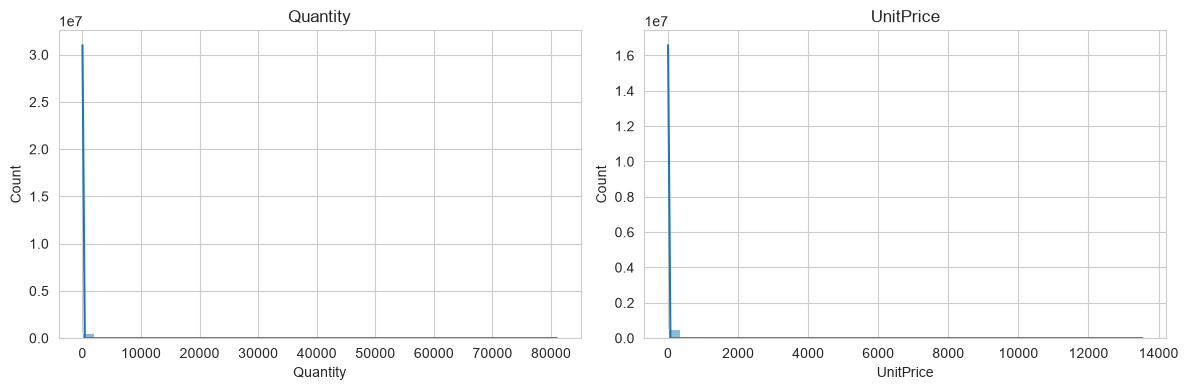

In [201]:
for col in ['Quantity','UnitPrice']:
    s=df[col]
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"---{col}---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.50):.2f}, P75={s.quantile(0.75):.2f}") 
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")      

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['Quantity'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('Quantity')
sns.histplot(df['UnitPrice'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('UnitPrice')
plt.tight_layout(); plt.show()


---
# PHẦN C — DEFINE THE QUESTION

## Câu hỏi 1: Quốc gia nào đóng góp doanh thu cao nhất, chiếm bao nhiêu % tổng doanh thu?

In [226]:
max_sales_country=df.groupby('Country')['Sales'].sum().sort_values(ascending=False)
max_country_name=max_sales_country.index[0]
country_max_price=max_sales_country.iloc[0]
top_phantram=(country_max_price/max_sales_country.sum())*100
print("Quoc gia: ",max_country_name)
print("Doanh thu: ", country_max_price)
print("Chiem so %: ", top_phantram)

Quoc gia:  United Kingdom
Doanh thu:  9025222.084
Chiem so %:  84.61131522893568


## Câu hỏi 2: Sản phẩm nào bán chạy nhất theo doanh thu?

In [233]:
top_product=df.groupby('Description')['Sales'].sum().sort_values(ascending=False)
print("San pham ban chay nhat theo doanh thu: ",top_product.index[0])

San pham ban chay nhat theo doanh thu:  DOTCOM POSTAGE


## Câu hỏi 3: Doanh số có tính mùa vụ theo tháng không?

YearMonth
2010-12     823746.14
2011-01     691364.56
2011-02     523631.89
2011-03     717639.36
2011-04     537808.62
2011-05     770536.02
2011-06     761739.90
2011-07     719221.19
2011-08     759138.38
2011-09    1058590.17
2011-10    1154979.30
2011-11    1509496.33
2011-12     638792.68
Freq: M, Name: Sales, dtype: float64


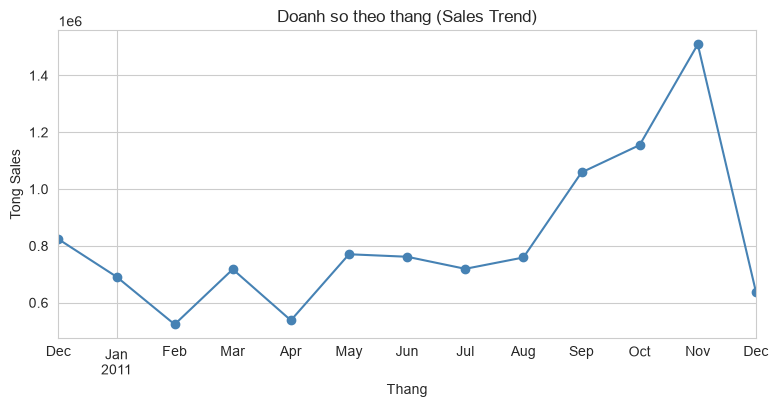

In [237]:
# Chuyen cot InvoiceDate ve dinh dang datetime va trich xuat thang-nam
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Tinh tong doanh so theo thang
monthly_sales = df.groupby('YearMonth')['Sales'].sum()
print(monthly_sales.round(2))

#Ve bieu do duong de xem xu huong mua vu
monthly_sales.plot(kind='line', marker='o', figsize=(9, 4), color='steelblue', title='Doanh so theo thang (Sales Trend)')
plt.ylabel('Tong Sales'); plt.xlabel('Thang'); plt.grid(True); plt.show()

## Câu hỏi 4: Giá trị đơn hàng trung bình (Average Order Value) khác nhau thế nào giữa các quốc gia?

In [ ]:
#  Tinh Tong Sales va So luong don hang duy nhat (InvoiceNo) theo tung Quoc gia
country_summary = df.groupby('Country').agg(
    total_sales=('Sales', 'sum'),
    total_orders=('InvoiceNo', 'nunique')
)

# Tinh AOV = Total Sales / Total Orders va sap xep giam dan
country_summary['AOV'] = country_summary['total_sales'] / country_summary['total_orders']
aov_sorted = country_summary['AOV'].sort_values(ascending=False)

print("--- TOP 10 QUỐC GIA CÓ AOV CAO NHẤT ---")
print(aov_sorted.head(10).round(2))

# 3. Ve bieu do Top 10 AOV
aov_sorted.head(10).plot(kind='bar', figsize=(8, 4), color='teal', title='Top 10 Quốc gia theo Giá trị đơn hàng TB (AOV)')
plt.ylabel('AOV'); plt.xticks(rotation=45); plt.show()

## Câu hỏi 5: Tỷ lệ giao dịch có dấu hiệu trả hàng/hủy (Quantity âm ở dữ liệu gốc) khác nhau thế nào giữa các quốc gia?

--- TOP QUỐC GIA CÓ TỶ LỆ TRẢ HÀNG/HỦY CAO NHẤT (>= 100 giao dịch) ---
           total_tx  cancelled_tx  cancel_rate_pct
Country                                           
USA             291           112            38.49
Malta           127            15            11.81
Japan           358            37            10.34
Australia      1259            74             5.88
Italy           803            45             5.60
Germany        9495           453             4.77
EIRE           8196           302             3.68
Poland          341            11             3.23
Singapore       229             7             3.06
Sweden          462            11             2.38


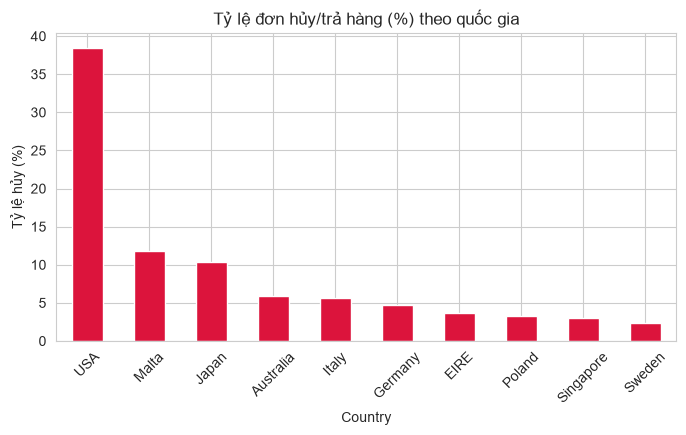

In [240]:
# Doc lai du lieu goc
df_raw = pd.read_csv(csv_path)

# Tao co danh dau giao dich huy/tra hang, quantity<0
df_raw['is_cancelled'] = df_raw['Quantity'] < 0

# Tinh tong so giao dich huy tra cua cac quoc gia
cancel_summary = df_raw.groupby('Country').agg(
    total_tx=('Quantity', 'count'),
    cancelled_tx=('is_cancelled', 'sum')
)
cancel_summary['cancel_rate_pct'] = (cancel_summary['cancelled_tx'] / cancel_summary['total_tx']) * 100

# Loc cac quoc gia co it nhat 100 giao dich
top_cancel_countries = cancel_summary[cancel_summary['total_tx'] >= 100].sort_values('cancel_rate_pct', ascending=False)

print("--- TOP QUỐC GIA CÓ TỶ LỆ TRẢ HÀNG/HỦY CAO NHẤT (>= 100 giao dịch) ---")
print(top_cancel_countries[['total_tx', 'cancelled_tx', 'cancel_rate_pct']].head(10).round(2))

# Bieu do
top_cancel_countries['cancel_rate_pct'].head(10).plot(kind='bar', figsize=(8, 4), color='crimson', title='Tỷ lệ đơn hủy/trả hàng (%) theo quốc gia')
plt.ylabel('Tỷ lệ hủy (%)'); plt.xticks(rotation=45); plt.show()

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể.

*The UK có doanh thu cao nhất. DOTCOM POSTAGE là sản phẩm bán chạy nhất. Doanh số tăng mạnh vào quý 4. The USA có nhiều lượt hủy nhất*